<img src="../pic/CU.png" style="width: 100%; display: block; margin: auto;">

# Курс по прогнозированию временных рядов
# Неделя 5.
# Механика прогноза: S, X и аналитические интервалы

В ноутбуках `01`–`03` мы разбирались, **как получить обученную модель**: что
происходит внутри `.fit()`, как выбрать порядки, чем отличаются библиотеки.
Модель у нас теперь есть. Дальше начинается то, ради чего всё затевалось, —
прогноз.

И вот здесь у большинства заканчивается понимание и начинается вера:
`.forecast(12)` возвращает двенадцать чисел и серую ленту вокруг них, и откуда
они взялись — непонятно. Сегодня мы это разбираем.

> **Главный принцип ноутбука: всё, что делает библиотека, мы повторяем руками
> на numpy и сверяем.** Не «примерно похоже», а совпадение до 8–9 знака.
> Если сошлось — значит, вы действительно поняли механику, а не пересказали
> формулу.

## Что мы разберём

| Раздел | Вопрос, на который отвечаем |
|---|---|
| 1 | Как SARIMA превращается в **одно линейное уравнение** и откуда там берутся лаги, которых никто не задавал |
| 2 | Как из этого уравнения получаются $\hat y_{T+1}, \hat y_{T+2}, \dots$ — **считаем руками** |
| 3 | Что именно добавляет `exog`: SARIMAX — это **регрессия с SARIMA-ошибками** |
| 4 | `predict` vs `forecast` vs `dynamic` — и почему красивый график часто **не прогноз** |
| 5 | Откуда берётся серая лента: **$\psi$-веса** и аналитические интервалы, тоже руками |
| 6 | Почему эта лента **слишком узкая** — проверяем покрытие эмпирически |

> **Соглашение об оформлении.** Блоки с 🔍 — то, на что стоит обратить внимание
> особо: там прячутся типичные ошибки. **⏱** — ячейки, которые считаются
> заметно дольше секунды; рядом указано ожидаемое время.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from numpy.polynomial.polynomial import polymul
from statsmodels.tsa.arima_process import arma2ma
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.simplefilter("ignore")

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["figure.dpi"] = 110

pd.set_option("display.width", 120)

---
# 1. SARIMA — это одно линейное уравнение

## 1.1. Лаг-оператор

Лаг-оператор $L$ сдвигает ряд на шаг назад: $L y_t = y_{t-1}$,
$L^k y_t = y_{t-k}$. Полезен он тем, что превращает громоздкие рекуррентные
формулы в **умножение многочленов**.

Полная запись SARIMA$(p,d,q)(P,D,Q)_m$ выглядит так:

$$
\underbrace{\varphi_p(L)}_{\text{AR}}\;
\underbrace{\Phi_P(L^m)}_{\text{сезонный AR}}\;
\underbrace{(1-L)^d (1-L^m)^D}_{\text{дифференцирование}}\, y_t
\;=\;
\underbrace{\theta_q(L)}_{\text{MA}}\;
\underbrace{\Theta_Q(L^m)}_{\text{сезонный MA}}\, \varepsilon_t
$$

где
$\varphi_p(L) = 1 - \varphi_1 L - \dots - \varphi_p L^p$,
$\Theta_Q(L^m) = 1 + \Theta_1 L^m + \dots + \Theta_Q L^{Qm}$ и так далее.

🔍 Обратите внимание на устройство формулы. **Сезонная часть — не отдельный
механизм и не «вторая модель».** Это ровно такие же многочлены, только от $L^m$
вместо $L$, и они просто **перемножаются** с несезонными. А при перемножении
многочленов степени складываются — поэтому в итоговом уравнении появляются
слагаемые, которых мы явно не задавали.

Сейчас мы это увидим.

## 1.2. Данные: ночёвки туристов в Австралии

Берём тот же ряд, что и в ноутбуке `02`, — квартальные данные о числе ночей,
проведённых туристами в Австралии. Он короткий, «чистый» и, главное, уже
знаком: порядки для него мы подбирали вручную в стратегии A.

In [2]:
raw_tour = pd.read_csv("../data/austourists.csv")

# 🔍 В файле одна строка помечена "Q3 2014" вместо "Q2 2014" — опечатка (разбор
# в ноутбуке 02). Ряд заведомо непрерывный квартальный, поэтому строим индекс
# явно от первой даты, а меткам из файла не доверяем.
tour = pd.Series(
    raw_tour["tourism"].astype(float).to_numpy(),
    index=pd.period_range("1999Q1", periods=len(raw_tour), freq="Q"),
    name="tourism",
)

print(f"наблюдений: {len(tour)},  период: {tour.index[0]} — {tour.index[-1]}")
tour.tail(3)

наблюдений: 68,  период: 1999Q1 — 2015Q4


2015Q2    47.69662
2015Q3    61.09777
2015Q4    66.05576
Freq: Q-DEC, Name: tourism, dtype: float64

## 1.3. Модель, с которой будем работать

Берём **SARIMA$(0,1,1)(0,1,1)_4$** — «airline model», классику Бокса–Дженкинса.
Выбор не случаен: в ней **нет AR-части**, а значит, прогноз считается по
конечному числу прошлых значений, и ручной счёт будет совпадать с библиотекой
практически до машинной точности. С AR-моделями мы тоже сверимся (раздел 2.3),
но там появится маленькая техническая поправка.

In [3]:
res = SARIMAX(tour, order=(0, 1, 1), seasonal_order=(0, 1, 1, 4)).fit(disp=False)
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                           tourism   No. Observations:                   68
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 4)   Log Likelihood                -144.282
Date:                           Sun, 06 Sep 2026   AIC                            294.564
Time:                                   18:30:44   BIC                            300.993
Sample:                               03-31-1999   HQIC                           297.093
                                    - 12-31-2015                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.6052      0.118     -5.137      0.000      -0.836      -0.374
ma.S.L4       -0.5089      0.140     -3.629      0.000      -0.784      -0.234
sigma2         5.5511      1.004      5.528      0.000       3.583       7.519
===================================================================================
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):                 5.22
Prob(Q):                              0.83   Prob(JB):                         0.07
Heteroskedasticity (H):               0.42   Skew:                            -0.62
Prob(H) (two-sided):                  0.05   Kurtosis:                         3.67
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Три числа — это всё, что оценила модель:

* `ma.L1` $= \theta_1$ — несезонный MA-коэффициент;
* `ma.S.L4` $= \Theta_1$ — сезонный MA-коэффициент (лаг 4, то есть год);
* `sigma2` $= \hat\sigma^2$ — дисперсия шума; в прогнозе она отвечает **только
  за ширину интервала** и никак не влияет на точечный прогноз.

## 1.4. Перемножаем полиномы

Для нашей модели уравнение выглядит так:

$$(1-L)(1-L^4)\, y_t = (1 + \theta_1 L)(1 + \Theta_1 L^4)\, \varepsilon_t$$

Раскроем обе стороны. Слева:

$$(1-L)(1-L^4) = 1 - L - L^4 + L^5$$

Справа:

$$(1 + \theta_1 L)(1 + \Theta_1 L^4) = 1 + \theta_1 L + \Theta_1 L^4 + \theta_1\Theta_1 L^5$$

Руками это делать не нужно: перемножение многочленов есть в numpy
(`polymul`), а сами многочлены `statsmodels` хранит в готовом виде.

In [4]:
# statsmodels хранит полиномы в атрибутах модели.
# Соглашение о знаках: AR-полином записан как [1, -φ₁, -φ₂, ...],
#                      MA-полином как [1, +θ₁, +θ₂, ...].
print("AR-полином  φ(L)·Φ(L⁴) :", res.polynomial_reduced_ar)  # AR-части нет → [1]
print("MA-полином  θ(L)·Θ(L⁴) :", res.polynomial_reduced_ma.round(4))

# дифференцирование в полином не входит — statsmodels держит его в модели
# пространства состояний. Допишем его сами:
ar_poly = res.polynomial_reduced_ar
ar_poly = polymul(ar_poly, [1, -1])  # (1 - L),  d = 1
ar_poly = polymul(ar_poly, [1, 0, 0, 0, -1])  # (1 - L⁴), D = 1
print("\nполная левая часть (1-L)(1-L⁴)·φ(L)Φ(L⁴):", ar_poly)

AR-полином  φ(L)·Φ(L⁴) : [1.]
MA-полином  θ(L)·Θ(L⁴) : [ 1.     -0.6052  0.      0.     -0.5089  0.308 ]

полная левая часть (1-L)(1-L⁴)·φ(L)Φ(L⁴): [ 1. -1.  0.  0. -1.  1.]


In [5]:
def show_equation(ar, ma):
    """Печатает уравнение модели в виде y_t = ... , читаемом человеком."""

    def term(coef, sym, lag):
        if abs(coef) < 1e-10:
            return None
        sign = "+" if coef > 0 else "−"
        return f"{sign} {abs(coef):.4f}·{sym}[t-{lag}]"

    # переносим y-часть вправо: y_t = -a_1 y_{t-1} - a_2 y_{t-2} - ...
    parts = [term(-ar[j], "y", j) for j in range(1, len(ar))]
    parts += ["+ e[t]"]
    parts += [term(ma[k], "e", k) for k in range(1, len(ma))]
    print("y[t] = " + " ".join(p for p in parts if p))


show_equation(ar_poly, res.polynomial_reduced_ma)

y[t] = + 1.0000·y[t-1] + 1.0000·y[t-4] − 1.0000·y[t-5] + e[t] − 0.6052·e[t-1] − 0.5089·e[t-4] + 0.3080·e[t-5]


Вот и всё уравнение модели:

$$y_t = y_{t-1} + y_{t-4} - y_{t-5}
       + \varepsilon_t + \theta_1\varepsilon_{t-1} + \Theta_1\varepsilon_{t-4}
       + \theta_1\Theta_1\,\varepsilon_{t-5}$$

🔍 **Главное наблюдение раздела.** Мы задали модель четырьмя числами
$(0,1,1)(0,1,1)_4$ и оценили всего **два** коэффициента. А в уравнении
участвуют лаги **1, 4 и 5** — и по $y$, и по $\varepsilon$. Лаг 5 никто не
просил: он появился сам, как $1 \cdot 4 + 1$ при перемножении полиномов.

Это и есть ответ на частый вопрос «почему сезонная модель ловит взаимодействие
сезона и тренда». Она его не «ловит» — оно алгебраически заложено в
произведении. Заодно понятно, почему коэффициент при $\varepsilon_{t-5}$ равен
ровно $\theta_1\Theta_1$, а не оценивается отдельно: **это ограничение**,
которое SARIMA накладывает на модель, и именно оно позволяет описывать
сезонность двумя параметрами вместо пяти.

---
# 2. Рецепт прогноза: три правила

Уравнение выше связывает $y_t$ с прошлым. Чтобы получить прогноз, нужно
сделать три вещи:

1. **Подставить $t := T + h$**, где $T$ — последнее наблюдение, $h$ — горизонт.
2. **Заменить всё неизвестное:**
   * будущие $y_{T+k}$ ($k \ge 1$) — на уже посчитанные прогнозы $\hat y_{T+k}$;
   * будущие ошибки $\varepsilon_{T+k}$ ($k \ge 1$) — на **нули**
     (их условное ожидание равно нулю: это и есть определение «шума»);
   * прошлые ошибки $\varepsilon_{T-k}$ ($k \ge 0$) — на **остатки модели**
     `res.resid`, они наблюдаемы после подгонки.
3. **Идти по $h$ по порядку**, от 1 и дальше: для $\hat y_{T+2}$ уже нужен
   $\hat y_{T+1}$.

🔍 Второй пункт объясняет, почему **точечный прогноз ARIMA всегда сходится к
прямой или к константе**. С ростом $h$ все MA-члены обнуляются (их лаги
уходят в будущее), а AR-члены затухают. Прогноз на 50 шагов вперёд по ARIMA —
это уже не «модель что-то знает», а просто продолжение уровня и тренда.

## 2.1. Считаем $\hat y_{T+1}$, $\hat y_{T+2}$, $\hat y_{T+3}$ явно

Сначала — совсем без функций, буквально по формуле, чтобы было видно каждое
слагаемое.

In [6]:
theta = res.params["ma.L1"]  # θ₁
Theta = res.params["ma.S.L4"]  # Θ₁

y = tour.to_numpy()  # наблюдения y_1 .. y_T
e = res.resid.to_numpy()  # остатки  ε_1 .. ε_T
T = len(y) - 1  # индекс последнего наблюдения

print(f"θ₁ = {theta:.6f},  Θ₁ = {Theta:.6f}")
print(f"последние y: {y[-5:].round(3)}")
print(f"последние ε: {e[-5:].round(3)}")

θ₁ = -0.605242,  Θ₁ = -0.508942
последние y: [59.834 73.257 47.697 61.098 66.056]
последние ε: [1.462 4.278 0.162 2.139 1.734]


In [7]:
# h = 1:  y[T+1] = y[T] + y[T-3] - y[T-4] + 0 + θ·e[T] + Θ·e[T-3] + θΘ·e[T-4]
#         (ε[T+1] — будущая ошибка, ставим 0)
f1 = y[T] + y[T - 3] - y[T - 4] + theta * e[T] + Theta * e[T - 3] + theta * Theta * e[T - 4]

# h = 2:  y[T+2] = ŷ[T+1] + y[T-2] - y[T-3] + 0 + θ·0 + Θ·e[T-2] + θΘ·e[T-3]
#         (ε[T+1] тоже в будущем → 0; поэтому член с θ исчез)
f2 = f1 + y[T - 2] - y[T - 3] + Theta * e[T - 2] + theta * Theta * e[T - 3]

# h = 3:  y[T+3] = ŷ[T+2] + y[T-1] - y[T-2] + Θ·e[T-1] + θΘ·e[T-2]
f3 = f2 + y[T - 1] - y[T - 2] + Theta * e[T - 1] + theta * Theta * e[T - 2]

manual = np.array([f1, f2, f3])
library = res.forecast(3).to_numpy()

pd.DataFrame(
    {"руками": manual, "res.forecast(3)": library, "расхождение": manual - library},
    index=["h=1", "h=2", "h=3"],
)

,руками,res.forecast(3),расхождение
h=1,76.702285,76.702285,-2.212076e-09
h=2,52.377152,52.377152,-4.960867e-10
h=3,64.739421,64.739421,-7.935483e-10


Расхождение порядка $10^{-9}$ — это шум округления при выводе коэффициентов,
а не разные вычисления. **Мы воспроизвели `forecast` вручную.**

Посмотрите ещё раз на строку `h = 2`: член $\theta_1 \varepsilon_{T+1}$ из неё
**исчез**, потому что $\varepsilon_{T+1}$ — будущая ошибка. Отсюда важное
следствие: у MA($q$)-модели влияние MA-части полностью пропадает начиная с
горизонта $h = q + 1$. Сезонная MA-часть с лагом 4 держится дольше — до
$h = 5$.

## 2.2. То же самое, но функцией

Явный код выше не масштабируется: для другой модели его придётся переписывать.
Напишем общую версию — она работает для любой SARIMA.

Идея: если полное уравнение записано как
$\sum_{j\ge0} a_j y_{t-j} = \sum_{k\ge0} m_k \varepsilon_{t-k}$ (где
$a_0 = m_0 = 1$), то

$$\hat y_t = -\sum_{j\ge1} a_j y_{t-j} + \sum_{k\ge1} m_k \varepsilon_{t-k}$$

In [8]:
def full_ar_poly(res):
    """Левая часть уравнения: AR-полиномы, умноженные на разности."""
    order, sorder = res.model.order, res.model.seasonal_order
    d, D, m = order[1], sorder[1], sorder[3]
    a = res.polynomial_reduced_ar
    for _ in range(d):
        a = polymul(a, [1, -1])  # (1 - L)
    for _ in range(D):
        a = polymul(a, [1] + [0] * (m - 1) + [-1])  # (1 - Lᵐ)
    return a


def manual_forecast(res, h):
    """Прогноз SARIMA на h шагов, посчитанный рекуррентно по уравнению."""
    a = full_ar_poly(res)  # коэффициенты при y
    m_ = res.polynomial_reduced_ma  # коэффициенты при ε
    y = list(res.model.endog[:, 0])
    e = list(res.resid)
    n_obs = len(y)  # всё, что дальше, — будущее

    out = []
    for _ in range(h):
        t = len(y)  # индекс прогнозируемой точки
        val = -sum(a[j] * y[t - j] for j in range(1, len(a)))
        # будущие ошибки заменяем нулями
        val += sum(m_[k] * (e[t - k] if t - k < n_obs else 0.0) for k in range(1, len(m_)))
        y.append(val)
        e.append(0.0)
        out.append(val)
    return np.array(out)


h = 8
cmp = pd.DataFrame(
    {"руками": manual_forecast(res, h), "библиотека": res.forecast(h).to_numpy()},
    index=[f"h={i}" for i in range(1, h + 1)],
)
cmp["|разница|"] = (cmp["руками"] - cmp["библиотека"]).abs()
cmp.round(9)

,руками,библиотека,|разница|
h=1,76.702285,76.702285,2.000000e-09
h=2,52.377152,52.377152,0.000000e+00
h=3,64.739421,64.739421,1.000000e-09
h=4,69.474117,69.474117,1.000000e-09
h=5,80.654618,80.654618,3.000000e-09
h=6,56.329486,56.329486,1.000000e-09
h=7,68.691755,68.691755,1.000000e-09
h=8,73.426451,73.426451,1.000000e-09


## 2.3. А если в модели есть AR-часть?

Проверим ту же функцию на моделях с AR-членами.

In [9]:
rows = []
for order, sorder in [
    ((0, 1, 1), (0, 1, 1, 4)),
    ((1, 1, 1), (1, 1, 1, 4)),
    ((2, 0, 1), (1, 1, 0, 4)),
]:
    r = SARIMAX(tour, order=order, seasonal_order=sorder).fit(disp=False)
    err = np.abs(manual_forecast(r, 8) - r.forecast(8).to_numpy()).max()
    rows.append({"спецификация": f"{order}{sorder}", "макс. расхождение": err})

pd.DataFrame(rows)

,спецификация,макс. расхождение
0,"(0, 1, 1)(0, 1, 1, 4)",2.794508e-09
1,"(1, 1, 1)(1, 1, 1, 4)",8.712794e-06
2,"(2, 0, 1)(1, 1, 0, 4)",1.360627e-04


🔍 Совпадение есть везде, но точность разная: $10^{-9}$ для чистой MA-модели и
$10^{-4}\dots10^{-5}$ там, где есть AR-часть. Причина не в ошибке в формуле, а в
**начальных условиях**.

`statsmodels` считает правдоподобие не по рекуррентной формуле, а фильтром
Калмана (ноутбук `01`, раздел 2). Первые несколько наблюдений фильтр
обрабатывает в «диффузном» режиме: у него ещё нет истории, чтобы посчитать
$\varepsilon_t$ честно. Наша рекурсия про это не знает и берёт `res.resid`
как есть. Для MA-модели эта разница затухает мгновенно, для AR — тянется
дальше через рекурсию. На практике $10^{-5}$ на фоне значений порядка 60 —
это $10^{-7}$ относительной ошибки, то есть неразличимо.

**Вывод раздела.** Прогноз ARIMA — это не «магия», а подстановка в линейное
уравнение с двумя соглашениями: будущие ошибки равны нулю, будущие значения
берутся из уже посчитанных прогнозов.

---
# 3. Что добавляет `X`: SARIMAX — это регрессия с SARIMA-ошибками

Буква **X** в названии значит «eXogenous»: внешние регрессоры. Формально
`statsmodels` строит вот такую модель:

$$
\boxed{\;y_t = \beta' x_t + n_t\;}
\qquad\text{где}\qquad
\varphi(L)\Phi(L^m)(1-L)^d(1-L^m)^D\, n_t = \theta(L)\Theta(L^m)\,\varepsilon_t
$$

То есть: **обычная линейная регрессия, у которой остаток $n_t$ — не белый шум,
а SARIMA-процесс.** Отсюда сразу два практических следствия.

**Следствие 1: $\beta$ читается как в обычной регрессии.** «Рост $x$ на
единицу даёт рост $y$ на $\beta$» — в тех же единицах, что и исходный ряд.
Это не всегда очевидно: можно было бы ожидать, что при $d=1$ модель работает с
разностями и $\beta$ означает что-то про приросты. Нет — регрессия строится на
**уровнях**, дифференцируется только остаток $n_t$.

**Следствие 2, ради которого существует ноутбук `05`:** чтобы посчитать
$\hat y_{T+h}$, нужно знать $x_{T+h}$. Модель не умеет прогнозировать свои
регрессоры — она считает их данными. Нет $x$ на горизонте — нет прогноза.

## 3.1. Данные: потребление и доходы в США

Квартальные темпы прироста расходов домохозяйств (`Consumption`) и
располагаемого дохода (`Income`) в США, 1970–2016. Ряд стационарен по
построению (это уже проценты прироста), так что $d = 0$ и вся конструкция
видна без лишних деталей.

,Consumption,Income
Time,,
2016-01-01,0.404682,0.519025
2016-04-01,1.047707,0.723721
2016-07-01,0.729598,0.644701


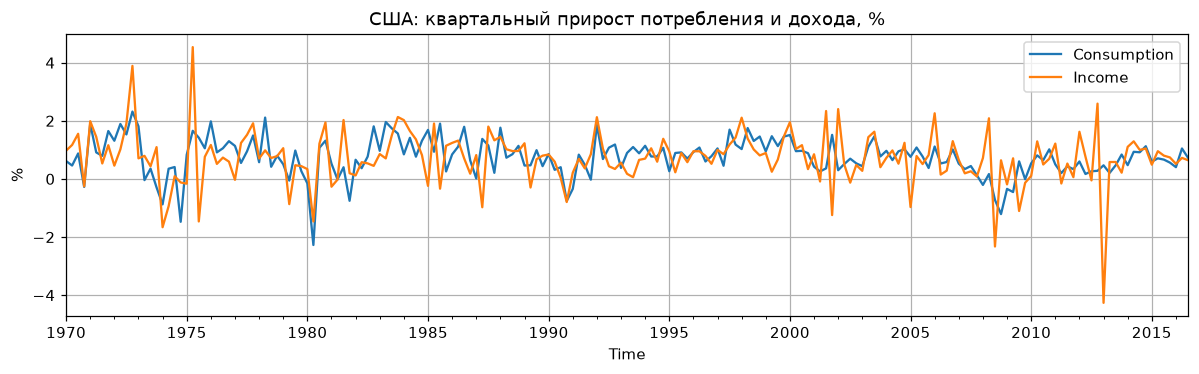

In [10]:
us = pd.read_csv("../data/us_change.csv", parse_dates=["Time"], index_col="Time").asfreq("QS")

fig, ax = plt.subplots(figsize=(11, 3.5))
us[["Consumption", "Income"]].plot(ax=ax)
ax.set(title="США: квартальный прирост потребления и дохода, %", ylabel="%")
fig.tight_layout()

us[["Consumption", "Income"]].tail(3)

In [11]:
mx = SARIMAX(
    us["Consumption"],
    exog=us[["Income"]],
    order=(1, 0, 2),
    trend="c",  # константа: средний уровень потребления при нулевом доходе
).fit(disp=False)
mx.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:            Consumption   No. Observations:                  187
Model:               SARIMAX(1, 0, 2)   Log Likelihood                -156.954
Date:                Sun, 06 Sep 2026   AIC                            325.908
Time:                        18:30:44   BIC                            345.295
Sample:                    01-01-1970   HQIC                           333.764
                         - 07-01-2016                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.1843      0.068      2.730      0.006       0.052       0.317
Income         0.2028      0.032      6.289      0.000       0.140       0.266
ar.L1          0.6923      0.115      6.040      0.000       0.468       0.917
ma.L1         -0.5759      0.121     -4.768      0.000      -0.813      -0.339
ma.L2          0.1983      0.071      2.789      0.005       0.059       0.338
sigma2         0.3133      0.025     12.588      0.000       0.264       0.362
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                30.33
Prob(Q):                              0.93   Prob(JB):                         0.00
Heteroskedasticity (H):               0.36   Skew:                            -0.43
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.77
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Читаем таблицу коэффициентов:

* `Income` $= \beta$ — **это регрессионная часть**. Значение ≈ 0.20 читается
  буквально: при росте дохода на 1 п.п. потребление растёт в среднем на
  0.20 п.п. в том же квартале.
* `ar.L1`, `ma.L1`, `ma.L2` — параметры ARMA(1,2) **для остатка** $n_t$.
* `intercept` — константа, о ней ниже (там ловушка).

## 3.2. Проверяем, что это действительно так

Утверждение «SARIMAX = регрессия с SARIMA-ошибками» легко проверить: если оно
верно, то, вычтя из $y$ регрессионную часть, мы должны получить ряд, на котором
та же ARMA(1,2) даст **те же самые** коэффициенты.

In [12]:
n_t = us["Consumption"] - mx.params["Income"] * us["Income"]  # y − βx
m_only_arma = SARIMAX(n_t, order=(1, 0, 2), trend="c").fit(disp=False)

pd.DataFrame(
    {
        "SARIMAX с exog": mx.params.drop("Income"),
        "SARIMA на (y − βx)": m_only_arma.params,
    }
).round(6)

,SARIMAX с exog,SARIMA на (y − βx)
intercept,0.184292,0.184321
ar.L1,0.692349,0.692286
ma.L1,-0.575916,-0.575846
ma.L2,0.198329,0.198343
sigma2,0.313267,0.313261


In [13]:
print(f"logL совместной модели : {mx.llf:.8f}")
print(f"logL модели на (y − βx): {m_only_arma.llf:.8f}")

logL совместной модели : -156.95401396
logL модели на (y − βx): -156.95401376


Коэффициенты совпадают до 4–5 знака, логарифмы правдоподобия — до 7-го.
Небольшая разница — это остановка оптимизатора по допуску, а не разные модели.
Утверждение проверено.

🔍 **Ловушка, на которой ломается эта проверка у всех.** В коде выше мы вычли
**только** $\beta x_t$, но оставили `trend="c"` во второй модели. Если вычесть
ещё и `intercept`, а вторую модель обучить с `trend="n"`, совпадения не будет:
`logL` разойдётся на 6 единиц.

Причина в том, как `statsmodels` понимает `trend`. Константа добавляется **не
к среднему уровню ряда**, а в правую часть уравнения для $n_t$:

$$\varphi(L)\, n_t = c + \theta(L)\varepsilon_t$$

так что средний уровень $n_t$ равен $c / (1 - \varphi_1)$, а не $c$. При
$\varphi_1 \approx 0.69$ это отличается втрое. Помните об этом, когда будете
интерпретировать `intercept` в `summary()`: **это не среднее значение ряда.**

## 3.3. Прогноз без `exog` невозможен

Финальный аргумент в пользу того, что $x$ — это данные, а не часть модели.

In [14]:
try:
    mx.forecast(4)
except Exception as err:
    print(f"{type(err).__name__}: {err}")

ValueError: Out-of-sample operations in a model with a regression component require additional exogenous values via the `exog` argument.


Модель прямо говорит: дайте `exog` на 4 шага вперёд. Вариантов, откуда его
взять, ровно шесть, и они разобраны в ноутбуке `05` — от «календарь известен
точно» до «спрогнозируем регрессор отдельной моделью и будем надеяться».

Здесь же нам важно другое следствие, к которому мы вернёмся в разделе 5.4:
если $x_{T+h}$ мы не знаем, а угадали, то **эта неопределённость в интервал
прогноза не попадёт**. Модель считает переданный ей `exog` точным.

---
# 4. `predict` vs `forecast` vs `dynamic`

Это раздел про самую распространённую ошибку в учебных ноутбуках по ARIMA —
включая некоторые ноутбуки этого курса прошлых лет.

У модели есть три разных способа «нарисовать линию», и они отвечают на **три
разных вопроса**:

| Вызов | Что считает | Какой вопрос |
|---|---|---|
| `predict(start, end)`, по умолчанию `dynamic=False` | одношаговые предсказания **по фактическим данным** | «насколько хорошо модель описывает то, что уже произошло?» |
| `predict(..., dynamic=True)` | многошаговый прогноз изнутри выборки, факт не подглядывается | «а что бы модель сказала, если бы её остановили здесь?» |
| `forecast(h)` / `get_forecast(h)` | прогноз за пределы выборки | «что будет дальше?» |

🔍 Опасность в том, что при `dynamic=False` линия **всегда** ложится на
фактический ряд почти идеально — даже у заведомо бесполезной модели. Потому что
на каждом шаге модель знает истинное $y_{t-1}$ и предсказывает всего на один
шаг вперёд. Такой график **нельзя** показывать как «прогноз модели»: это график
качества одношаговой подгонки.

Смотрим на всё три на одной картинке.

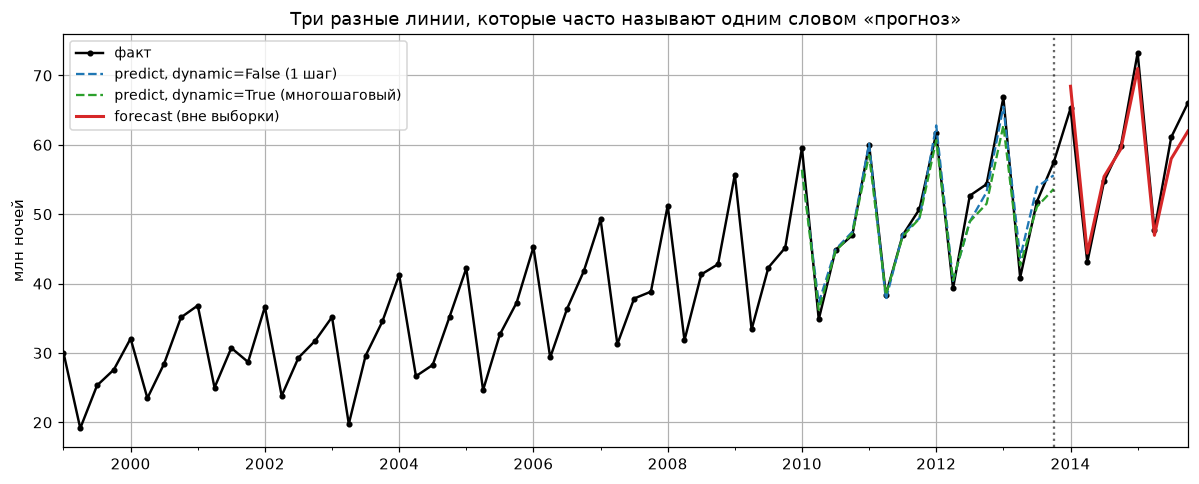

In [15]:
n_test = 8  # последние 2 года откладываем
tour_train, tour_test = tour.iloc[:-n_test], tour.iloc[-n_test:]
r_tr = SARIMAX(tour_train, order=(0, 1, 1), seasonal_order=(0, 1, 1, 4)).fit(disp=False)

start = len(tour_train) - 16  # рисуем последние 4 года обучения

pred_static = r_tr.get_prediction(start=start).predicted_mean  # dynamic=False
pred_dynamic = r_tr.get_prediction(start=start, dynamic=True).predicted_mean
fc = r_tr.get_forecast(n_test).predicted_mean

fig, ax = plt.subplots(figsize=(11, 4.5))
tour.plot(ax=ax, color="black", lw=1.6, marker="o", ms=3, label="факт")
pred_static.plot(ax=ax, color="C0", ls="--", label="predict, dynamic=False (1 шаг)")
pred_dynamic.plot(ax=ax, color="C2", ls="--", label="predict, dynamic=True (многошаговый)")
fc.plot(ax=ax, color="C3", lw=2, label="forecast (вне выборки)")
ax.axvline(tour_train.index[-1].ordinal, color="black", ls=":", alpha=0.6)
ax.set(title="Три разные линии, которые часто называют одним словом «прогноз»", ylabel="млн ночей")
ax.legend(fontsize=9)
fig.tight_layout()

Разница видна глазом. Синяя линия почти сливается с фактом — и это ничего не
говорит о прогнозных свойствах модели. Зелёная (та же модель, но без
подглядывания) заметно грубее и уже начинает «уплощаться». Красная —
единственная честная.

Сравним численно: посчитаем RMSE на **одном и том же** отрезке обучающей
выборки для статического и динамического режимов.

In [16]:
window = tour_train.iloc[-16:]
rmse = lambda a, b: float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))

pd.DataFrame(
    {
        "RMSE": [
            rmse(window, pred_static.iloc[: len(window)]),
            rmse(window, pred_dynamic.iloc[: len(window)]),
            rmse(tour_test, fc),
        ]
    },
    index=[
        "in-sample, dynamic=False (1 шаг)",
        "in-sample, dynamic=True (до 16 шагов)",
        "out-of-sample, forecast (8 шагов)",
    ],
).round(3)

,RMSE
"in-sample, dynamic=False (1 шаг)",1.835
"in-sample, dynamic=True (до 16 шагов)",2.164
"out-of-sample, forecast (8 шагов)",2.356


На `austourists` разрыв умеренный: 1.84 против 2.36, то есть одношаговая
ошибка занижает реальную примерно на 25 %. Так и должно быть — ряд короткий,
чистый, модель ему подходит.

А теперь посмотрим, во что та же ошибка превращается на ряде, который **плохо
прогнозируется в принципе**.

## 4.1. Классическая иллюзия: «ARIMA отлично предсказывает акции»

Возьмём цену акций Google. Этот ряд нам ещё понадобится в разделе 5, так что
загрузим его сейчас.

In [17]:
googl = (
    pd.read_csv("../data/GOOGL.csv", parse_dates=["Date"], index_col="Date")["Close"]
    .asfreq("B")  # биржевые дни
    .ffill()  # выходные/праздники — переносим последнее значение
)
print(f"{len(googl)} наблюдений, {googl.index.min():%Y-%m-%d} — {googl.index.max():%Y-%m-%d}")

280 наблюдений, 2015-01-02 — 2016-01-28


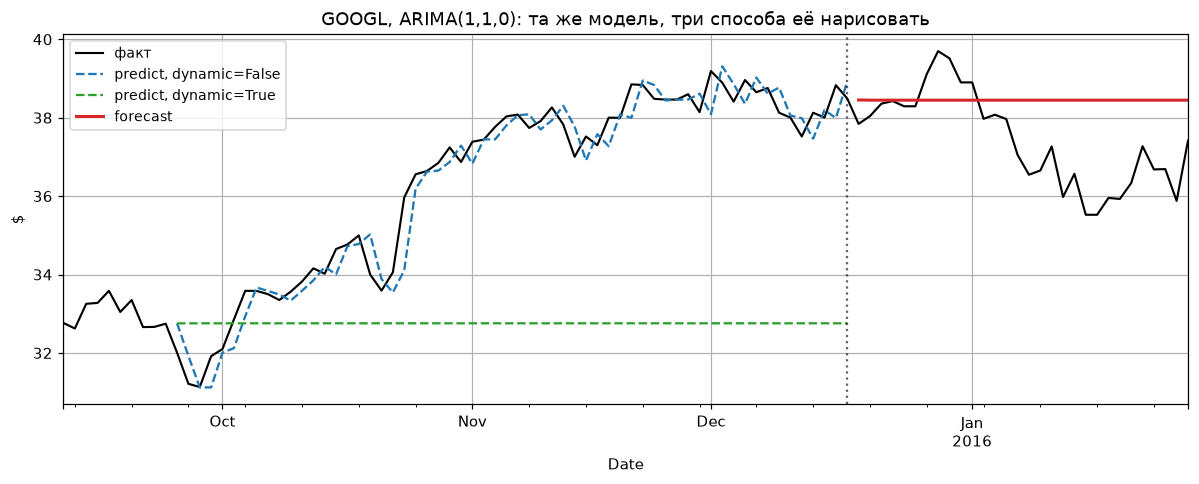

In [18]:
g_train, g_test = googl.iloc[:-30], googl.iloc[-30:]
r_g = SARIMAX(g_train, order=(1, 1, 0)).fit(disp=False)

g_start = len(g_train) - 60
g_static = r_g.get_prediction(start=g_start).predicted_mean
g_dynamic = r_g.get_prediction(start=g_start, dynamic=True).predicted_mean
g_fc = r_g.get_forecast(30).predicted_mean

fig, ax = plt.subplots(figsize=(11, 4.5))
googl.iloc[-100:].plot(ax=ax, color="black", lw=1.4, label="факт")
g_static.plot(ax=ax, color="C0", ls="--", label="predict, dynamic=False")
g_dynamic.plot(ax=ax, color="C2", ls="--", label="predict, dynamic=True")
g_fc.plot(ax=ax, color="C3", lw=2, label="forecast")
ax.axvline(g_train.index[-1], color="black", ls=":", alpha=0.6)
ax.set(title="GOOGL, ARIMA(1,1,0): та же модель, три способа её нарисовать", ylabel="$")
ax.legend(fontsize=9)
fig.tight_layout()

In [19]:
g_window = g_train.iloc[-60:]
pd.DataFrame(
    {
        "RMSE": [
            rmse(g_window, g_static),
            rmse(g_window, g_dynamic),
            rmse(g_test, g_fc),
        ]
    },
    index=[
        "in-sample, dynamic=False (1 шаг)",
        "in-sample, dynamic=True (до 60 шагов)",
        "out-of-sample, forecast (30 шагов)",
    ],
).round(3)

,RMSE
"in-sample, dynamic=False (1 шаг)",0.524
"in-sample, dynamic=True (до 60 шагов)",4.347
"out-of-sample, forecast (30 шагов)",1.570


🔍 Вот теперь разница драматична: **0.52 против 4.35 — в восемь раз.**

Синяя линия лежит на факте практически идеально, повторяя каждый изгиб. Именно
такие картинки подписывают «модель ARIMA точно предсказывает котировки». На
самом деле модель здесь говорит буквально следующее: «завтра будет примерно
столько же, сколько сегодня». Она копирует ряд с задержкой в один шаг — и
выглядит блестяще ровно потому, что ей на каждом шаге показывают ответ.

Зелёная и красная линии показывают, что модель знает на самом деле: почти
прямую. Для случайного блуждания это и есть оптимальный прогноз.

**Правило.** Любое число, которое вы называете «точностью прогноза», должно
быть посчитано либо на отложенной выборке, либо на rolling-origin CV. Никогда —
на `fittedvalues` и никогда — по `predict` с `dynamic=False`.

---
# 5. Откуда берётся серая лента: аналитические интервалы

Теперь — вторая половина вывода `get_forecast`. Прогнозный интервал уровня
95 % строится так:

$$\hat y_{T+h} \pm z_{0.975}\cdot \sqrt{v_{T+h|T}}, \qquad z_{0.975} = 1.96$$

Весь вопрос — в $v_{T+h|T}$, дисперсии ошибки прогноза на $h$ шагов.

## 5.1. Один шаг: $v_{T+1|T} = \hat\sigma^2$

Начнём с самого простого случая. На один шаг вперёд единственное, чего мы не
знаем, — это $\varepsilon_{T+1}$. Значит, дисперсия ошибки прогноза равна
дисперсии шума. Это верно для **любой** ARIMA-модели.

In [20]:
f = res.get_forecast(8)
sf = f.summary_frame(alpha=0.05)

print(f"σ̂² из модели      : {res.params['sigma2']:.6f}")
print(f"σ̂  = √σ̂²          : {np.sqrt(res.params['sigma2']):.6f}")
print(f"mean_se при h = 1  : {sf['mean_se'].iloc[0]:.6f}")

σ̂² из модели      : 5.551064
σ̂  = √σ̂²          : 2.356070
mean_se при h = 1  : 2.356070


## 5.2. Много шагов: $\psi$-веса

Для $h > 1$ неизвестных ошибок несколько. Чтобы понять, как они складываются,
любую ARIMA переписывают в виде **бесконечного MA-ряда** (представление
Вольда):

$$y_t = \sum_{j=0}^{\infty} \psi_j \varepsilon_{t-j}, \qquad \psi_0 = 1$$

Коэффициенты $\psi_j$ получаются делением MA-полинома на AR-полином. В такой
записи ошибка прогноза на $h$ шагов — это просто сумма тех $\psi$-взвешенных
шоков, которые ещё не произошли:

$$y_{T+h} - \hat y_{T+h} = \sum_{j=0}^{h-1}\psi_j\,\varepsilon_{T+h-j}
\qquad\Longrightarrow\qquad
\boxed{\;v_{T+h|T} = \hat\sigma^2 \sum_{j=0}^{h-1}\psi_j^2\;}$$

При $h = 1$ сумма состоит из одного члена $\psi_0^2 = 1$ — получаем результат
раздела 5.1.

🔍 Формула сразу объясняет две вещи. Во-первых, **интервал может только
расширяться** с ростом $h$: мы прибавляем к сумме неотрицательные слагаемые.
Во-вторых, скорость расширения полностью определяется тем, как ведут себя
$\psi_j$: у стационарной модели они затухают и сумма сходится (интервал выходит
на плато), а при наличии дифференцирования — нет.

В `statsmodels` $\psi$-веса считает `arma2ma`.

In [21]:
ar_full = full_ar_poly(res)  # включая (1-L)(1-L⁴)
ma_full = res.polynomial_reduced_ma

psi = arma2ma(ar_full, ma_full, lags=8)
print("ψ-веса:", psi.round(4))

# v_{T+h} = σ² · Σ ψ²  — накопленная сумма квадратов
se_manual = np.sqrt(res.params["sigma2"] * np.cumsum(psi**2))

z = 1.959963985  # квантиль N(0,1) уровня 0.975
lo_manual = f.predicted_mean.to_numpy() - z * se_manual
hi_manual = f.predicted_mean.to_numpy() + z * se_manual

pd.DataFrame(
    {
        "ψ_h": psi,
        "se руками": se_manual,
        "se библиотека": sf["mean_se"].to_numpy(),
        "нижняя руками": lo_manual,
        "нижняя библиотека": sf["mean_ci_lower"].to_numpy(),
    },
    index=[f"h={i}" for i in range(1, 9)],
).round(8)

ψ-веса: [1.     0.3948 0.3948 0.3948 0.8858 0.5886 0.5886 0.5886]


,ψ_h,se руками,se библиотека,нижняя руками,нижняя библиотека
h=1,1.000000,2.356070,2.356070,72.084473,72.084473
h=2,0.394758,2.533003,2.533003,47.412557,47.412557
h=3,0.394758,2.698360,2.698360,59.450732,59.450732
h=4,0.394758,2.854153,2.854153,63.880080,63.880080
h=5,0.885816,3.535809,3.535809,73.724561,73.724561
h=6,0.588607,3.798046,3.798046,48.885453,48.885453
h=7,0.588607,4.043311,4.043311,60.767011,60.767011
h=8,0.588607,4.274526,4.274526,65.048534,65.048534


Совпадение полное. **Серая лента — это накопленная сумма квадратов
$\psi$-весов, умноженная на $\hat\sigma^2$.** Больше в ней ничего нет — и это
важно для раздела 6.

Обратите внимание на сами $\psi$: они **не затухают**, а держатся около 0.4 и
скачком растут на лаге 5. Так и должно быть: у модели $d = 1$ и $D = 1$, ряд
нестационарен, шок в него входит навсегда.

## 5.3. Инструмент: `plot_forecast`

Дальше картинка «факт + прогноз + два уровня интервала» понадобится много раз.
Оформим её функцией — она пригодится и в ноутбуках `05`, `06`.

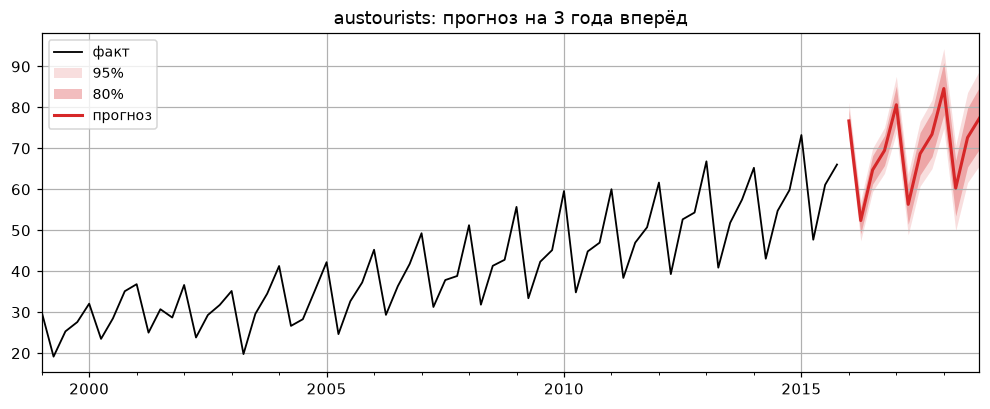

In [22]:
def plot_forecast(y, res, h, levels=(80, 95), exog=None, ax=None, title="", tail=None):
    """Факт + прогноз на h шагов + вложенные интервалы указанных уровней."""
    fc = res.get_forecast(h, exog=exog)
    mean = fc.predicted_mean
    idx = mean.index

    if ax is None:
        _, ax = plt.subplots(figsize=(11, 4))

    hist = y.iloc[-tail:] if tail else y
    hist.plot(ax=ax, color="black", lw=1.2, label="факт")

    # от широкого к узкому, чтобы узкий рисовался поверх
    for lvl, alpha in zip(sorted(levels, reverse=True), (0.15, 0.3, 0.45)):
        ci = fc.conf_int(alpha=1 - lvl / 100)
        ax.fill_between(idx, ci.iloc[:, 0], ci.iloc[:, 1], color="C3", alpha=alpha, lw=0,
                        label=f"{lvl}%")

    mean.plot(ax=ax, color="C3", lw=2, label="прогноз")
    ax.set_title(title)
    ax.legend(fontsize=9)
    return ax


plot_forecast(tour, res, h=12, title="austourists: прогноз на 3 года вперёд");

## 5.4. Как $d$ влияет на скорость расширения интервала

Из формулы $v_{T+h} = \hat\sigma^2\sum\psi_j^2$ следует, что скорость роста
ленты определяется поведением $\psi$-весов, а оно — порядком дифференцирования.
Проверим на уже загруженной цене акций Google: одна и та же AR(1)-модель,
отличается только $d$.

,d=0,d=1,d=2
ширина при h=1,2.23,2.22,2.70
при h=10,6.82,7.53,38.25
при h=30,11.06,13.12,184.21
при h=300,18.73,41.58,5620.21
при h=600,18.87,58.81,15864.28
во сколько раз шире к h=30,4.97,5.90,68.10


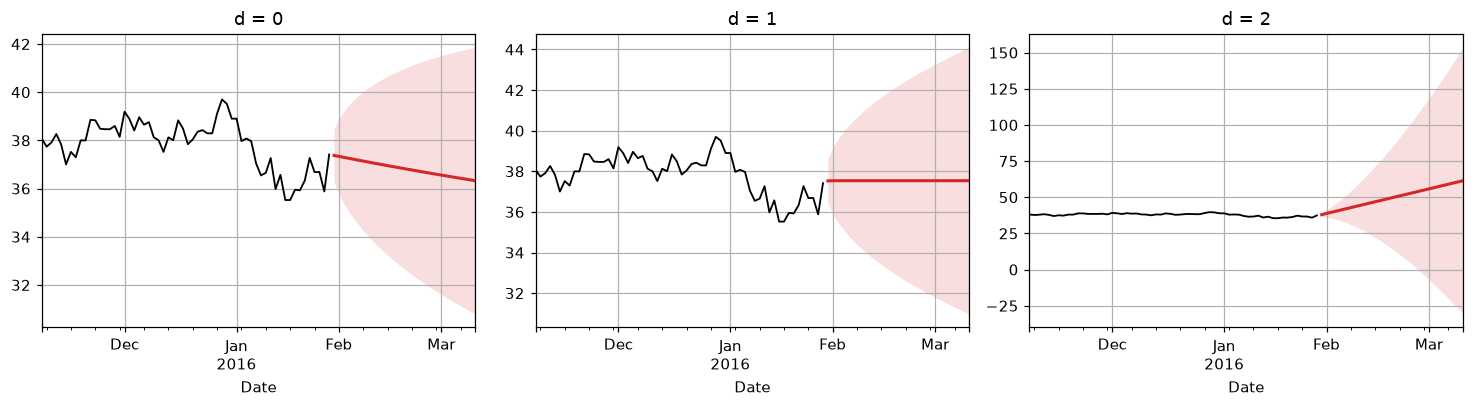

In [23]:
H = 30
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8), sharey=False)
widths, phis = {}, {}
for ax, d in zip(axes, [0, 1, 2]):
    r = SARIMAX(googl, order=(1, d, 0), trend="c" if d == 0 else "n").fit(disp=False)
    plot_forecast(googl, r, H, levels=(95,), ax=ax, tail=60, title=f"d = {d}")
    # длинный горизонт — чтобы увидеть, выходит ли ширина на плато
    ci = r.get_forecast(600).conf_int()
    widths[d] = (ci.iloc[:, 1] - ci.iloc[:, 0]).to_numpy()
    phis[d] = r.params["ar.L1"]
    ax.legend().remove()
fig.tight_layout()

pd.DataFrame(
    {f"d={d}": [w[0], w[9], w[29], w[299], w[599], w[29] / w[0]] for d, w in widths.items()},
    index=["ширина при h=1", "при h=10", "при h=30", "при h=300", "при h=600", "во сколько раз шире к h=30"],
).round(2)

🔍 Три принципиально разных режима:

* $d = 0$ (стационарная модель) — $\psi_j = \hat\varphi_1^{\,j}$ затухают
  геометрически, сумма сходится, **интервал выходит на плато**. Модель уверена,
  что ряд вернётся к своему среднему, и дальше неопределённость не растёт.
* $d = 1$ (случайное блуждание) — все $\psi_j$ близки к 1, дисперсия растёт
  как $\hat\sigma^2 h$, ширина — как $\sqrt{h}$ (проверьте: $\sqrt{30} = 5.5$,
  а в таблице 5.9).
* $d = 2$ — $\psi_j$ растут линейно, ширина растёт как $h^{1.5}$. Интервал
  разлетается почти мгновенно: к $h = 30$ он шире исходного в 68 раз.

🔍 Обратите внимание на колонку $d = 0$: к $h = 30$ она выросла в 5 раз, почти
как случайное блуждание, и «плато» видно только к $h \approx 300$. Причина — в
оценке $\hat\varphi_1$:

In [24]:
for d, p in phis.items():
    extra = f",  1/(1−φ̂) ≈ {1 / (1 - p):.0f} шагов" if d == 0 else ""
    print(f"d = {d}:  φ̂₁ = {p:+.4f}{extra}")

d = 0:  φ̂₁ = +0.9930,  1/(1−φ̂) ≈ 143 шагов
d = 1:  φ̂₁ = +0.0741
d = 2:  φ̂₁ = -0.4497


У стационарной модели $\hat\varphi_1 = 0.993$ — формально меньше единицы, но
характерное время возврата к среднему $1/(1-\hat\varphi_1) \approx 143$ шага.
На горизонте 30 дней такая модель **неотличима** от случайного блуждания, и её
интервал ведёт себя так же.

Это полезное напоминание: качественные выводы («стационарная модель выходит на
плато») верны асимптотически, а на вашем горизонте важно не только значение
$d$, но и то, **насколько близко корни AR-полинома подошли к единице**.

**Практический вывод.** Лишняя разность обходится дорого не в точечном
прогнозе (он изменится мало), а в интервале. Если ваш 95 %-й интервал через
30 шагов становится шире всего исторического размаха ряда — первым делом
проверьте $d$ и $D$, скорее всего вы передифференцировали.

## 5.5. Что происходит с интервалом, когда есть `X`

А теперь — обещанная проверка, ради которой стоит читать этот раздел до конца.

Возьмём спрос на электроэнергию в штате Виктория (сквозной ряд семинара):
суточное потребление зависит от температуры сильно и нелинейно — жара включает
кондиционеры, холод включает обогреватели. Добавим `Temperature` и
`Temperature²` как регрессоры и построим **два прогноза с разным `exog`**:
по фактической температуре и по сценарию «жара 35 °C каждый день».

In [25]:
raw = pd.read_csv("../data/vic_elec.csv", parse_dates=["Time"])
raw["Date"] = pd.to_datetime(raw["Date"])

# получасовые данные → суточные
daily = raw.groupby("Date").agg(
    Demand=("Demand", "sum"),
    Temperature=("Temperature", "max"),
    Holiday=("Holiday", "first"),
)
daily.index.freq = "D"
daily["Demand"] /= 1000  # ГВт·ч
vic = daily.loc["2014"]

X_vic = pd.DataFrame(
    {
        "temp": vic["Temperature"],
        "temp2": vic["Temperature"] ** 2,  # нелинейность: и жара, и холод повышают спрос
        "workday": (~(vic["Holiday"].astype(bool) | vic.index.dayofweek.isin([5, 6]))).astype(float),
    },
    index=vic.index,
)

n_te = 14
y_tr, y_te = vic["Demand"].iloc[:-n_te], vic["Demand"].iloc[-n_te:]
X_tr, X_te = X_vic.iloc[:-n_te], X_vic.iloc[-n_te:]

r_vic = SARIMAX(y_tr, exog=X_tr, order=(1, 0, 1), seasonal_order=(0, 1, 1, 7)).fit(disp=False)
r_vic.params.round(4)

temp       -7.7334
temp2       0.1814
workday    35.2286
ar.L1       0.8548
ma.L1      -0.0205
ma.S.L7    -0.8550
sigma2     41.2204
dtype: float64

In [26]:
X_hot = X_te.copy()
X_hot["temp"] = 35.0  # сценарий: две недели жары
X_hot["temp2"] = 35.0**2

f_fact = r_vic.get_forecast(n_te, exog=X_te).summary_frame(alpha=0.05)
f_hot = r_vic.get_forecast(n_te, exog=X_hot).summary_frame(alpha=0.05)

pd.DataFrame(
    {
        "прогноз (факт. T)": f_fact["mean"],
        "ширина PI (факт. T)": f_fact["mean_ci_upper"] - f_fact["mean_ci_lower"],
        "прогноз (T = 35°)": f_hot["mean"],
        "ширина PI (T = 35°)": f_hot["mean_ci_upper"] - f_hot["mean_ci_lower"],
    }
).round(4).head(7)

,прогноз (факт. T),ширина PI (факт. T),прогноз (T = 35°),ширина PI (T = 35°)
2014-12-18,218.0285,25.1672,250.6943,25.1672
2014-12-19,211.8883,32.7766,245.4987,32.7766
2014-12-20,186.2863,37.3698,219.7449,37.3698
2014-12-21,206.6060,40.3974,214.5223,40.3974
2014-12-22,218.7790,42.4736,250.6741,42.4736
2014-12-23,221.4544,43.9287,250.1675,43.9287
2014-12-24,217.0703,44.9623,250.9019,44.9623


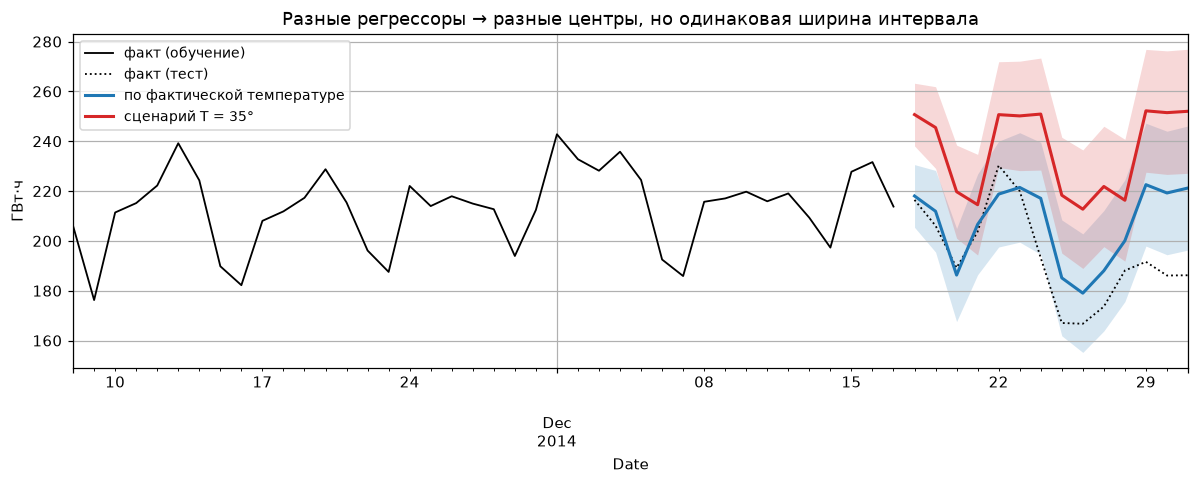

In [27]:
fig, ax = plt.subplots(figsize=(11, 4.5))
y_tr.iloc[-40:].plot(ax=ax, color="black", lw=1.2, label="факт (обучение)")
y_te.plot(ax=ax, color="black", lw=1.2, ls=":", label="факт (тест)")

for fr, c, lab in [(f_fact, "C0", "по фактической температуре"), (f_hot, "C3", "сценарий T = 35°")]:
    ax.plot(fr.index, fr["mean"], color=c, lw=2, label=lab)
    ax.fill_between(fr.index, fr["mean_ci_lower"], fr["mean_ci_upper"], color=c, alpha=0.18, lw=0)

ax.set(title="Разные регрессоры → разные центры, но одинаковая ширина интервала", ylabel="ГВт·ч")
ax.legend(fontsize=9)
fig.tight_layout()

🔍 **Ключевой результат ноутбука.** Центры прогнозов разошлись на десятки
ГВт·ч, а ширина интервалов совпала **до последнего знака**.

Так и должно быть по формуле: $v_{T+h} = \hat\sigma^2\sum\psi_j^2$ — в ней нет
ни $x$, ни $\beta$. Модель считает переданный `exog` **точно известным**, как
календарь.

А теперь представьте, что температуру на две недели вперёд мы взяли из
прогноза погоды, у которого своя ошибка ±4 °C. Эта ошибка в ленту **не попала**.
Интервал говорит «спрос будет в этих границах», хотя честное утверждение —
«спрос будет в этих границах, **если** температура окажется ровно такой».

Это не баг `statsmodels`, а прямое следствие того, как определена модель. Но
знать об этом обязательно: если ваш `exog` сам является прогнозом, объявленные
95 % — завышенная оценка вашей уверенности. Способы с этим бороться — в
ноутбуке `05`, способ 4.

---
# 6. Почему аналитические интервалы слишком узкие

Мы разобрали интервал по косточкам и теперь можем честно перечислить, что в
него **не входит**:

1. **Неопределённость оценок параметров.** В формуле стоят $\hat\theta$,
   $\hat\sigma^2$, но они сами оценены по конечной выборке и имеют стандартные
   ошибки (те самые, что в `summary()`). Формула обращается с ними как с
   точными числами.
2. **Неопределённость выбора модели.** Порядки $(p,d,q)(P,D,Q)_m$ мы выбрали
   по AIC на этих же данных (ноутбук `02`) — и делаем вид, что они даны свыше.
3. **Предположение о нормальности** ошибок. У финансовых и спросовых рядов
   хвосты тяжелее нормальных, а волатильность непостоянна.
4. **Предположение о неизменности структуры** на всём горизонте.
5. **Неопределённость `exog`** — раздел 5.5.

Всё это работает в одну сторону: **реальный интервал шире объявленного.**
Проверим это эмпирически.

## 6.1. Как измерять: покрытие на rolling-origin CV

Методика простая и универсальная:

1. берём момент времени $s$, обучаем модель только на данных до него;
2. строим 95 %-й интервал на $h$ шагов вперёд;
3. смотрим, попал ли **фактический** $y_{s+h}$ внутрь;
4. сдвигаем $s$ и повторяем;
5. доля попаданий — **эмпирическое покрытие**. У корректного 95 %-го интервала
   оно должно быть около 95 %.

In [28]:
def coverage(y, order, sorder=(0, 0, 0, 0), trend="n", H=4, start=None, step=1, alpha=0.05):
    """Доля попаданий факта в (1-alpha)-интервал, отдельно по каждому горизонту h."""
    start = start or int(len(y) * 0.65)
    hits, widths, n_win = np.zeros(H), np.zeros(H), 0

    for s in range(start, len(y) - H, step):
        r = SARIMAX(y.iloc[:s], order=order, seasonal_order=sorder, trend=trend).fit(disp=False)
        fr = r.get_forecast(H).summary_frame(alpha=alpha)
        act = y.iloc[s : s + H].to_numpy()
        lo, hi = fr["mean_ci_lower"].to_numpy(), fr["mean_ci_upper"].to_numpy()
        hits += ((act >= lo) & (act <= hi)).astype(int)
        widths += hi - lo
        n_win += 1

    return pd.DataFrame(
        {"покрытие 95%": hits / n_win, "средняя ширина": widths / n_win},
        index=[f"h={i}" for i in range(1, H + 1)],
    ), n_win

## 6.2. Ряд, на котором всё в порядке

⏱ ~5 с. Потребление в США: ряд стационарный, спокойный, без выбросов.

In [29]:
cov_us, n_win = coverage(us["Consumption"], order=(1, 0, 2), trend="c", H=4, start=120)
print(f"окон: {n_win}")
cov_us.round(3)

окон: 63


,покрытие 95%,средняя ширина
h=1,0.984,2.477
h=2,0.984,2.518
h=3,0.968,2.602
h=4,0.968,2.642


Покрытие 97–98 % при заявленных 95 %. Интервал даже слегка **консервативен** —
так бывает на коротких горизонтах у хорошо специфицированных стационарных
моделей.

## 6.3. Ряд, на котором всё ломается

⏱ ~10 с. Цена акций Google: тяжёлые хвосты, кластеризация волатильности,
новостные скачки — всё то, чего модель с постоянной $\sigma^2$ не предполагает.

In [30]:
cov_g, n_win = coverage(googl, order=(1, 1, 0), H=5, start=120, step=2)
print(f"окон: {n_win}")
cov_g.round(3)

окон: 78


,покрытие 95%,средняя ширина
h=1,0.910,2.062
h=2,0.923,3.107
h=3,0.897,3.901
h=4,0.897,4.561
h=5,0.910,5.137


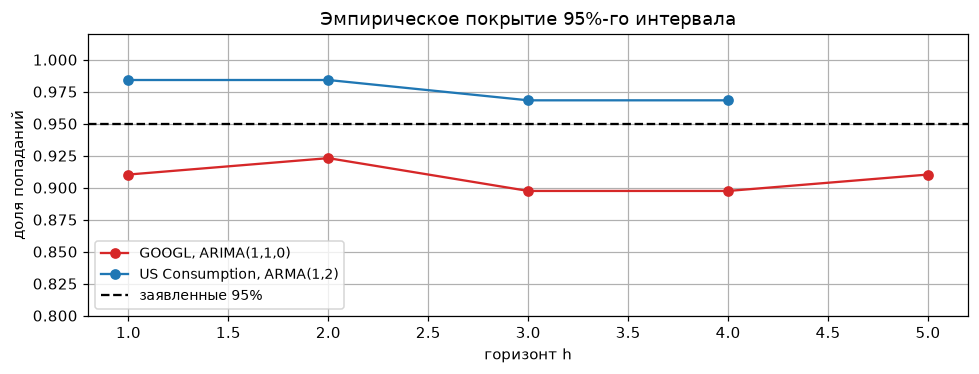

In [31]:
fig, ax = plt.subplots(figsize=(9, 3.5))
x = np.arange(1, 6)
ax.plot(x, cov_g["покрытие 95%"], "o-", color="C3", label="GOOGL, ARIMA(1,1,0)")
ax.plot(np.arange(1, 5), cov_us["покрытие 95%"], "o-", color="C0", label="US Consumption, ARMA(1,2)")
ax.axhline(0.95, color="black", ls="--", label="заявленные 95%")
ax.set(xlabel="горизонт h", ylabel="доля попаданий", ylim=(0.8, 1.02),
       title="Эмпирическое покрытие 95%-го интервала")
ax.legend(fontsize=9)
fig.tight_layout()

🔍 На GOOGL покрытие — **90–92 % вместо 95 %**. То есть факт вылетает за
границы примерно вдвое чаще, чем обещано. В переводе на бизнес-язык: событие,
которое вы называете «случается раз в 20 периодов», на самом деле случается
раз в 10.

Разница между двумя рядами показательна. Аналитический интервал — не «всегда
врёт», он **верен ровно настолько, насколько верны его предпосылки**. На
спокойном стационарном ряду с нормальными остатками он работает. На финансовом
ряду с тяжёлыми хвостами — нет.

## 6.4. Что с этим делать

| Подход | Идея | Где смотреть |
|---|---|---|
| Диагностика остатков | Проверить нормальность и отсутствие автокорреляции — то есть предпосылки | ноутбук `06`, шаг 7 |
| Симуляция вместо формулы | `res.simulate()` / бутстрап остатков: не предполагать нормальность | `5.8` |
| Conformal prediction | Строить интервал по эмпирическому распределению ошибок на калибровочной выборке — покрытие гарантировано без предположений о распределении | `5.9` |
| Всегда мерить покрытие | Никогда не верить заявленному уровню, не проверив его на CV | функция `coverage` выше |

Первое правило простое: **сообщая интервал, сообщайте и его измеренное
покрытие.** Одна строчка «95 %-й PI, эмпирическое покрытие на CV — 91 %»
честнее, чем красивая лента без комментария.

---
# Итоги

## Что нужно унести из этого ноутбука

1. **SARIMA — это одно линейное уравнение.** Сезонная часть не отдельный
   механизм, а множитель. Из перемножения полиномов появляются «перекрёстные»
   лаги ($t-5$ у модели с $m = 4$), которых никто явно не задавал, и жёсткие
   ограничения на их коэффициенты ($\theta_1\Theta_1$).

2. **Прогноз = подстановка в это уравнение** с двумя правилами: будущие ошибки
   заменяем нулями, будущие значения — уже посчитанными прогнозами. Мы
   воспроизвели `forecast()` на numpy с расхождением $10^{-9}$.

3. **Отсюда — «уплощение» прогноза.** MA-часть перестаёт работать после
   $h = q$, AR-часть затухает. Далёкий прогноз ARIMA — это уровень плюс тренд,
   и никакой дополнительной информации в нём нет.

4. **SARIMAX = регрессия с SARIMA-ошибками.** $\beta$ читается как в обычной
   регрессии, на уровнях. Но `intercept` при `trend='c'` — **не** среднее ряда,
   а константа внутри ARMA-уравнения.

5. **`dynamic=False` — не прогноз.** Это цепочка одношаговых предсказаний по
   фактическим данным. На `austourists` метрика по ней занижена на 25 %, на
   GOOGL — **в 8 раз**.

6. **Интервал = $\hat\sigma^2\sum_{j<h}\psi_j^2$.** Всё. Скорость расширения
   задаётся $\psi$-весами, а они — порядком дифференцирования: плато при
   $d = 0$, $\sqrt{h}$ при $d = 1$, $h^{1.5}$ при $d = 2$. Но «плато» может
   оказаться далеко за вашим горизонтом, если $\hat\varphi_1$ близко к 1.

7. **Неопределённость `exog` в интервал не входит.** Два прогноза с разной
   температурой дали разные центры и **побайтово одинаковые** ширины.

8. **Заявленные 95 % надо проверять.** На спокойном ряду покрытие 97 %, на
   финансовом — 91 %. Меряйте его на rolling-origin CV и сообщайте вместе с
   интервалом.

## Чек-лист «я построил прогноз»

1. Это `forecast` / `get_forecast`, а не `predict` с `dynamic=False`?
2. Метрика посчитана на отложенной выборке или на CV, а не на `fittedvalues`?
3. Если есть `exog`: значения на горизонте известны точно или это тоже прогноз?
   Если прогноз — интервал заведомо оптимистичен, скажите об этом явно.
4. Интервал не разлетается неправдоподобно широко? Если да — проверьте $d$, $D$.
5. Покрытие измерено на CV и указано рядом с интервалом?
6. Остатки прошли диагностику (Ljung–Box, QQ)? Без этого предпосылки формулы
   интервала не проверены.

---

**Дальше:** ноутбук `05` — шесть способов получить `exog` на горизонт прогноза,
от календаря и гармоник Фурье до лаговых регрессоров, и честная проверка
«а помогает ли регрессор вообще».